In [72]:
import kagglehub
import os
path=kagglehub.dataset_download("aniketyadav1/kmeans")
os.listdir(path)

Using Colab cache for faster access to the 'kmeans' dataset.


['k-means.csv']

In [73]:
import pandas as pd
df=pd.read_csv(os.path.join(path,"k-means.csv"))
df.head()

,name,age,income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


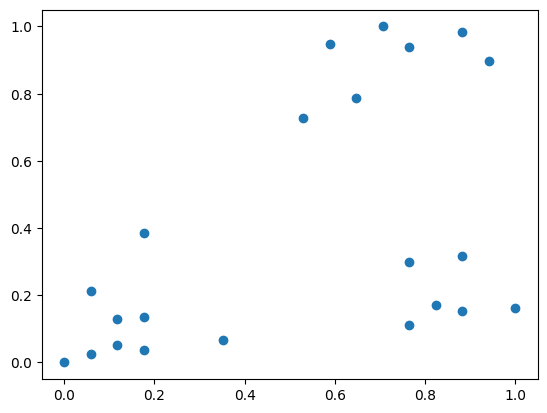

In [74]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(df[['income']])
df['income']=scaler.transform(df[['income']])

scaler.fit(df[['age']])
df['age']=scaler.transform(df[['age']])
plt.scatter(df['age'],df['income'])

In [75]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3)
df['cluster']=km.fit_predict(df[['age','income']])

In [76]:
df1=df[df['cluster']==1]
df0=df[df['cluster']==0]
df2=df[df['cluster']==2]

/tmp/ipykernel_16472/94933630.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


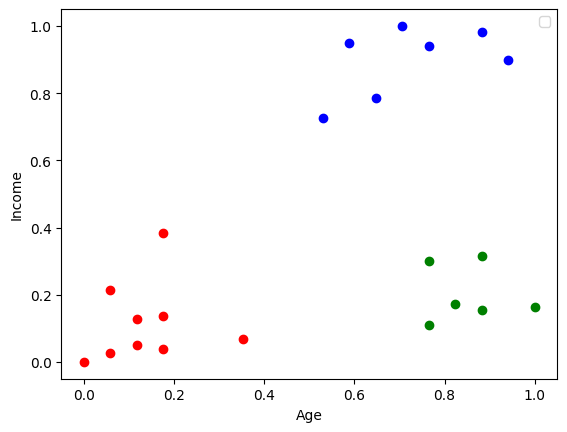

In [77]:

plt.xlabel("Age")
plt.ylabel("Income")
plt.scatter(df1['age'],df1['income'], color='green')
plt.scatter(df2['age'],df2['income'], color='blue')
plt.scatter(df0['age'],df0['income'], color='red')
plt.legend()

## Computing the right number for K
elbow plot

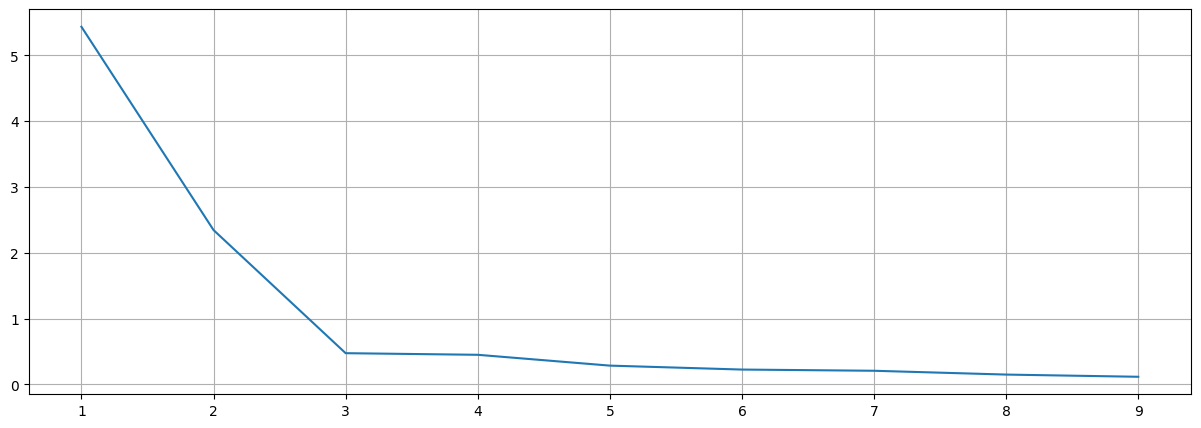

In [78]:
k_range=range(1,10)
sse=[]
for i in k_range:
    km=KMeans(n_clusters=i)
    km.fit(df[['age','income']])
    sse.append(km.inertia_)
plt.figure(figsize= (15,5))
plt.grid(visible=True,which='both')
plt.plot(k_range,sse)

# Exercise

## Loading the data

In [79]:
from sklearn.datasets import load_iris;
df=load_iris()
df=pd.DataFrame(df.data, columns=df.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## Preprocessing
- Scaling the data for more accurate clustering

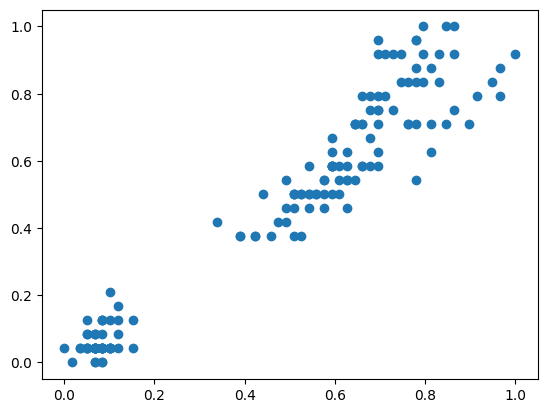

In [80]:
df['petal length (cm)']=scaler.fit_transform(df[['petal length (cm)']])
df['petal width (cm)']=scaler.fit_transform(df[['petal width (cm)']])

plt.scatter(df['petal length (cm)'],df['petal width (cm)'])


## Finding the value of K

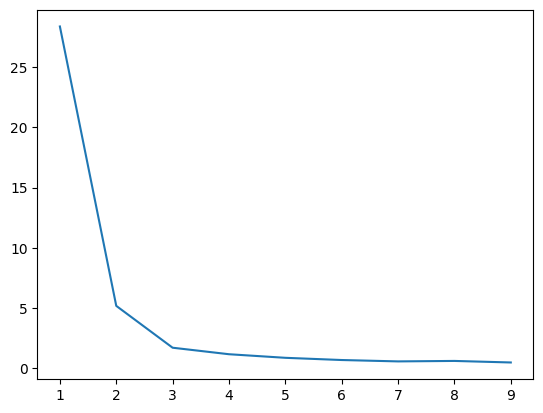

In [81]:
elbow_chart={"x":[],"y":[]}
for k in range(1,10):
    km=KMeans(n_clusters=k)
    km.fit(df[['petal length (cm)', 'petal width (cm)']])
    elbow_chart['x'].append(k)
    elbow_chart['y'].append(km.inertia_)

plt.plot(elbow_chart['x'],elbow_chart['y'])

## Training the model

In [82]:
km=KMeans(n_clusters=2)
km.fit(df[['petal length (cm)', 'petal width (cm)']])
df['cluster']=km.fit_predict(df[['petal length (cm)', 'petal width (cm)']])
df0=df[df['cluster']==0]
df1=df[df['cluster']==1]



## Visual Result

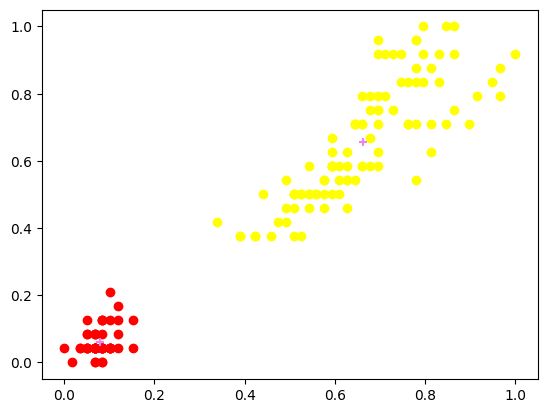

In [ ]:

plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],color='red')
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color='yellow')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1], color="violet",marker='+')